In [1]:
import duckdb
import pandas as pd

conn = duckdb.connect("../data/warehouse.duckdb")
print("Connected to DuckDB")

Connected to DuckDB


# Revenue Trends:

In [2]:
df = conn.execute("""
    SELECT ticker, fiscal_year, revenue_bn, gross_margin_pct, revenue_growth_pct
    FROM main_gold.gold_revenue_trends
    WHERE ticker IN ('AAPL', 'MSFT', 'NVDA')
    ORDER BY ticker, fiscal_year
""").fetchdf()

print(f"Rows: {len(df)}")
df

Rows: 70


,ticker,fiscal_year,revenue_bn,gross_margin_pct,revenue_growth_pct
0,AAPL,2016,78.35,38.51,-63.67
1,AAPL,2016,215.64,39.08,NaN
2,AAPL,2017,229.23,NaN,404.83
3,AAPL,2017,229.23,38.47,0.00
4,AAPL,2017,88.29,38.41,-61.48
...,...,...,...,...,...
65,NVDA,2021,16.68,NaN,0.00
66,NVDA,2022,26.91,NaN,61.40
67,NVDA,2022,26.91,64.93,0.00
68,NVDA,2023,26.97,56.93,0.22


# Company Comparison:

In [3]:
df2 = conn.execute("""
    SELECT ticker, report_year, revenue_bn, gross_margin_pct, net_margin_pct, revenue_cagr_3yr
    FROM main_gold.gold_company_comparison
    ORDER BY revenue_bn DESC
""").fetchdf()

df2

,ticker,report_year,revenue_bn,gross_margin_pct,net_margin_pct,revenue_cagr_3yr
0,AMZN,2024,637.96,NaN,9.29,NaN
1,AAPL,2024,391.04,46.21,23.97,NaN
2,GOOGL,2024,350.02,NaN,NaN,NaN
3,GOOGL,2024,350.02,NaN,28.60,NaN
4,MSFT,2024,245.12,69.76,35.96,NaN
5,META,2024,164.50,NaN,37.91,NaN
6,IBM,2024,62.75,56.65,9.60,NaN
7,NVDA,2024,60.92,72.72,48.85,NaN
8,CSCO,2024,53.80,64.73,19.18,NaN
9,INTC,2024,53.10,32.66,-35.32,NaN


# Margin Trends:

In [4]:
df3 = conn.execute("""
    SELECT ticker, fiscal_year, gross_margin_pct, operating_margin_pct, industry_avg_gross_margin
    FROM main_gold.gold_margin_trends
    WHERE ticker = 'MSFT'
    ORDER BY fiscal_year
""").fetchdf()

df3

,ticker,fiscal_year,gross_margin_pct,operating_margin_pct,industry_avg_gross_margin
0,MSFT,2016,61.66,30.61,60.30
1,MSFT,2016,64.23,30.62,60.30
2,MSFT,2016,64.04,28.61,60.30
3,MSFT,2017,65.28,28.96,59.78
4,MSFT,2017,64.52,30.06,59.78
5,MSFT,2017,66.26,31.41,59.78
6,MSFT,2017,61.74,30.01,59.78
7,MSFT,2018,61.74,31.59,61.95
8,MSFT,2018,65.94,34.23,61.95
9,MSFT,2018,65.25,31.77,61.95


# Quick visualization:

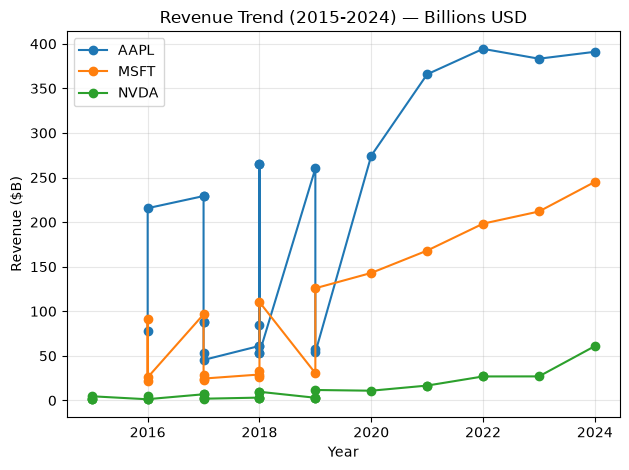

In [6]:
import matplotlib.pyplot as plt

# Revenue growth for AAPL, MSFT, NVDA
for ticker in ['AAPL', 'MSFT', 'NVDA']:
    data = conn.execute(f"""
        SELECT fiscal_year, revenue_bn
        FROM main_gold.gold_revenue_trends
        WHERE ticker = '{ticker}'
        ORDER BY fiscal_year
    """).fetchdf()
    plt.plot(data["fiscal_year"], data["revenue_bn"], marker="o", label=ticker)

plt.title("Revenue Trend (2015-2024) — Billions USD")
plt.xlabel("Year")
plt.ylabel("Revenue ($B)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Close connection:

In [7]:
conn.close()
print("Done")

Done
